# 03 - Backtest de la Stratégie

## Configuration

| Paramètre | Valeur |
|-----------|--------|
| Signal | 12-1 momentum |
| Long | Top 10 actions |
| Short | Bottom 10 actions |
| Rebalancement | Mensuel |
| Pondération | Equal-weight |
| Coûts | 10 bps par trade |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from src.data_loader import load_universe_data, load_benchmark_data
from src.backtest import run_backtest, compute_drawdowns, analyze_drawdowns
from src.metrics import compute_metrics, compute_annual_returns, format_metrics_table
from src.config import get_config

config = get_config()

In [2]:
prices = load_universe_data(verbose=False)
benchmark = load_benchmark_data(verbose=False)

print(f"Période: {prices.index[0].date()} - {prices.index[-1].date()}")

Période: 2005-01-31 - 2024-12-31


## Exécution du backtest

In [3]:
# Long-Short
config.PORTFOLIO_TYPE = 'long_short'
results_ls = run_backtest(prices, benchmark, config)

# Long-Only
config.PORTFOLIO_TYPE = 'long_only'
results_lo = run_backtest(prices, benchmark, config)

print("Backtest terminé.")

Backtest terminé.


c:\Users\tilou\Cross-Sectional-Momentum-actions-US\notebooks\..\src\backtest.py:43: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()
c:\Users\tilou\Cross-Sectional-Momentum-actions-US\notebooks\..\src\backtest.py:43: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()


## Performance cumulée

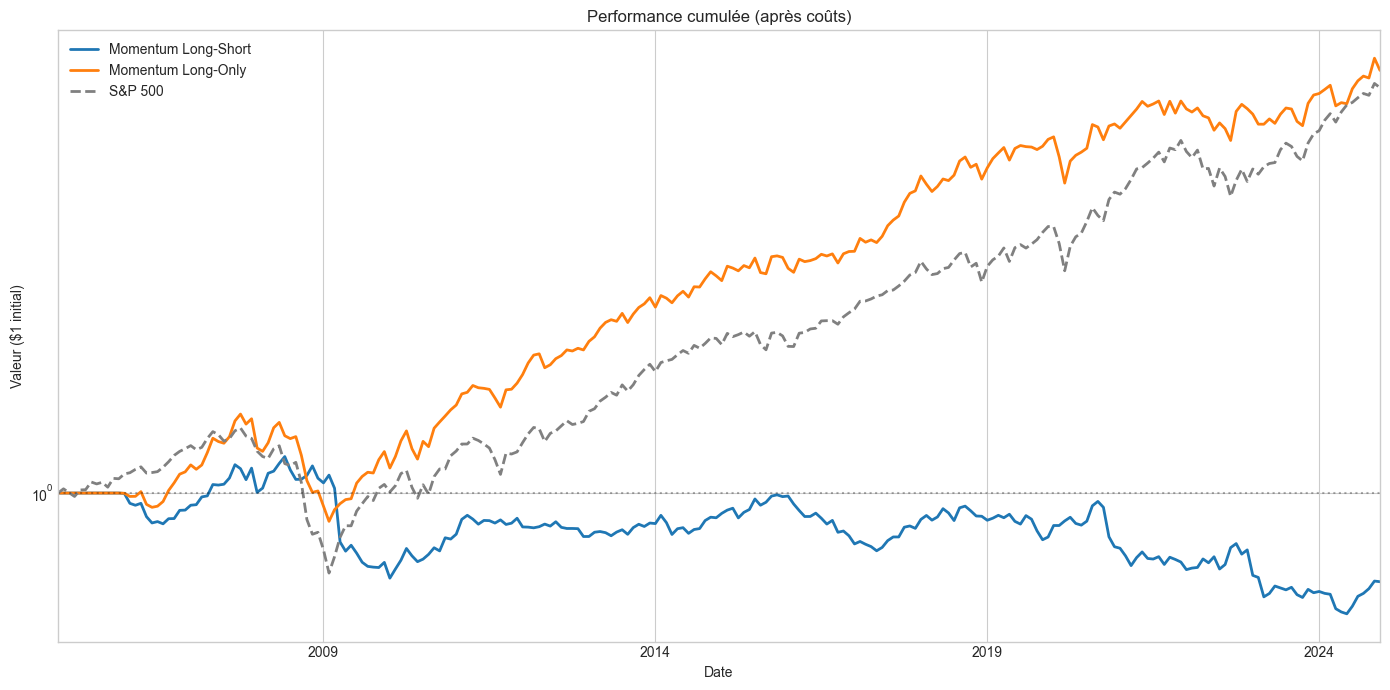

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

results_ls.cumulative_returns.plot(ax=ax, label='Momentum Long-Short', linewidth=2)
results_lo.cumulative_returns.plot(ax=ax, label='Momentum Long-Only', linewidth=2)
results_ls.cumulative_benchmark.plot(ax=ax, label='S&P 500', linewidth=2, color='gray', linestyle='--')

ax.axhline(1, color='black', linestyle=':', alpha=0.3)
ax.set_title('Performance cumulée (après coûts)')
ax.set_ylabel('Valeur ($1 initial)')
ax.set_yscale('log')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Métriques de performance

In [5]:
metrics_ls = compute_metrics(
    results_ls.strategy_returns,
    results_ls.cumulative_returns,
    results_ls.turnover,
    results_ls.transaction_costs
)

metrics_lo = compute_metrics(
    results_lo.strategy_returns,
    results_lo.cumulative_returns,
    results_lo.turnover,
    results_lo.transaction_costs
)

metrics_bench = compute_metrics(
    results_ls.benchmark_returns,
    results_ls.cumulative_benchmark
)

comparison = pd.DataFrame({
    'Long-Short': [
        f"{metrics_ls.cagr:.2%}",
        f"{metrics_ls.volatility:.2%}",
        f"{metrics_ls.sharpe_ratio:.2f}",
        f"{metrics_ls.max_drawdown:.2%}",
        f"{metrics_ls.calmar_ratio:.2f}",
        f"{metrics_ls.avg_turnover:.2%}",
    ],
    'Long-Only': [
        f"{metrics_lo.cagr:.2%}",
        f"{metrics_lo.volatility:.2%}",
        f"{metrics_lo.sharpe_ratio:.2f}",
        f"{metrics_lo.max_drawdown:.2%}",
        f"{metrics_lo.calmar_ratio:.2f}",
        f"{metrics_lo.avg_turnover:.2%}",
    ],
    'S&P 500': [
        f"{metrics_bench.cagr:.2%}",
        f"{metrics_bench.volatility:.2%}",
        f"{metrics_bench.sharpe_ratio:.2f}",
        f"{metrics_bench.max_drawdown:.2%}",
        f"{metrics_bench.calmar_ratio:.2f}",
        "N/A",
    ],
}, index=['CAGR', 'Volatilité', 'Sharpe', 'Max Drawdown', 'Calmar', 'Turnover moy.'])

print("Comparaison des stratégies:")
comparison

Comparaison des stratégies:


,Long-Short,Long-Only,S&P 500
CAGR,-2.14%,10.88%,10.41%
Volatilité,12.72%,15.39%,14.97%
Sharpe,-0.10,0.75,0.74
Max Drawdown,-53.64%,-40.81%,-50.78%
Calmar,-0.04,0.27,0.21
Turnover moy.,72.67%,35.75%,N/A


## Rendements annuels

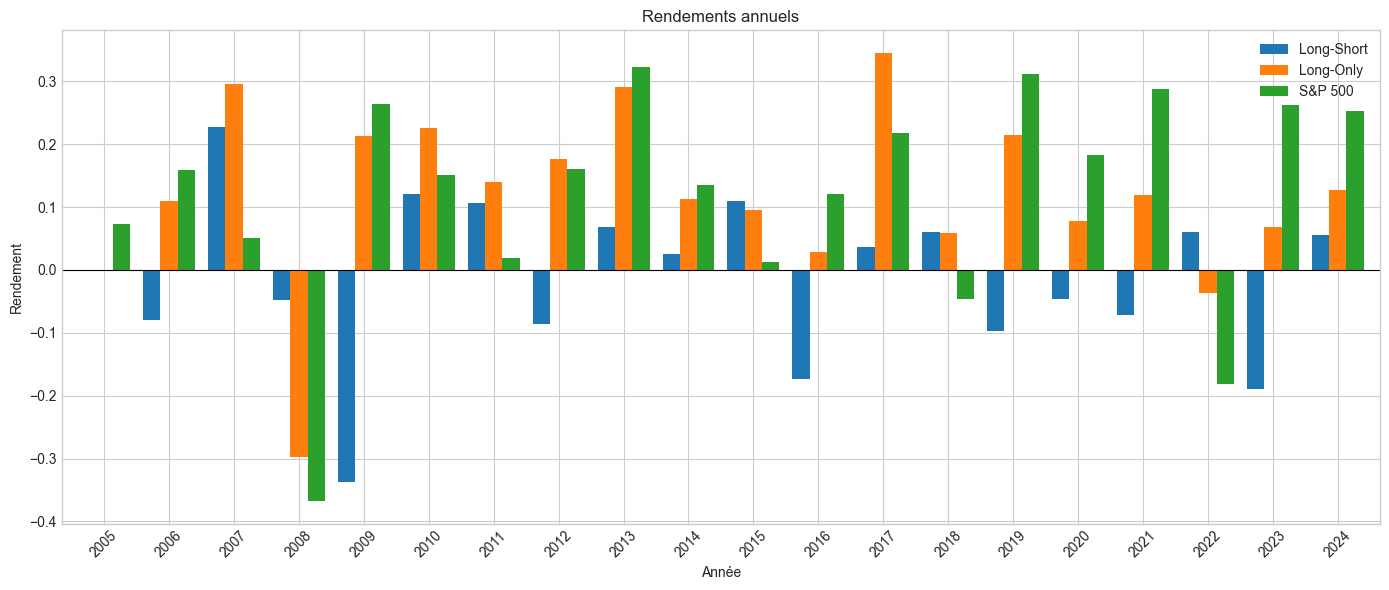


Rendements annuels (détail):


C:\Users\tilou\AppData\Local\Temp\ipykernel_14348\1828073631.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annual_table.applymap(lambda x: f"{x:.2%}")


,Long-Short,Long-Only,S&P 500
Date,,,
2005,0.00%,0.00%,7.23%
2006,-7.99%,10.91%,15.85%
2007,22.75%,29.63%,5.15%
2008,-4.81%,-29.73%,-36.80%
2009,-33.72%,21.21%,26.35%
2010,12.08%,22.64%,15.06%
2011,10.70%,13.94%,1.89%
2012,-8.54%,17.62%,15.99%
2013,6.81%,29.09%,32.31%


In [6]:
annual_ls = compute_annual_returns(results_ls.strategy_returns)
annual_lo = compute_annual_returns(results_lo.strategy_returns)
annual_bench = compute_annual_returns(results_ls.benchmark_returns)

annual_table = pd.DataFrame({
    'Long-Short': annual_ls,
    'Long-Only': annual_lo,
    'S&P 500': annual_bench,
})

# Barplot
fig, ax = plt.subplots(figsize=(14, 6))
annual_table.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rendements annuels')
ax.set_ylabel('Rendement')
ax.set_xlabel('Année')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nRendements annuels (détail):")
annual_table.applymap(lambda x: f"{x:.2%}")

## Analyse des drawdowns

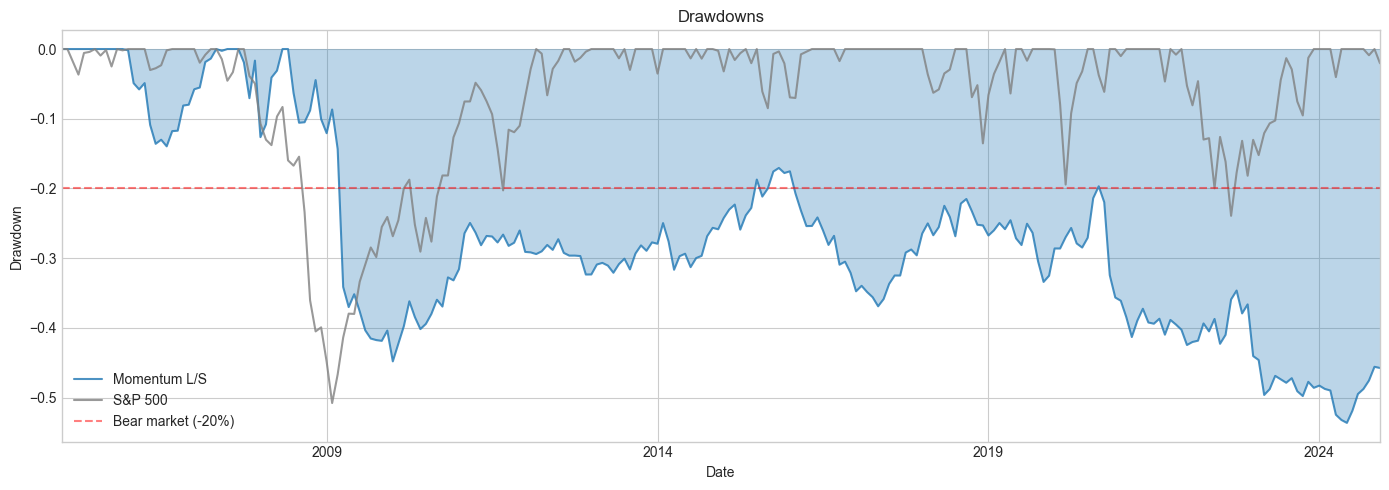

In [7]:
dd_ls = compute_drawdowns(results_ls.cumulative_returns)
dd_bench = compute_drawdowns(results_ls.cumulative_benchmark)

fig, ax = plt.subplots(figsize=(14, 5))

dd_ls.plot(ax=ax, label='Momentum L/S', alpha=0.8)
dd_bench.plot(ax=ax, label='S&P 500', alpha=0.8, color='gray')

ax.fill_between(dd_ls.index, 0, dd_ls, alpha=0.3)
ax.axhline(-0.2, color='red', linestyle='--', alpha=0.5, label='Bear market (-20%)')

ax.set_title('Drawdowns')
ax.set_ylabel('Drawdown')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Top 5 pires drawdowns
dd_analysis = analyze_drawdowns(results_ls.cumulative_returns)
print("Top 5 pires drawdowns (Long-Short):")
dd_analysis.head()

Top 5 pires drawdowns (Long-Short):


,start,trough,end,depth,duration_months
0,2008-07-31,2024-06-30,2024-12-31,-0.536350,198
1,2006-01-31,2006-08-31,2007-05-31,-0.139617,17
2,2007-10-31,2008-01-31,2008-05-31,-0.126404,8
3,2007-06-30,2007-06-30,2007-07-31,-0.002601,2


## Stress Tests: COVID-19 et Bear Market 2022

In [9]:
def stress_test(results, start, end, period_name):
    returns = results.strategy_returns.loc[start:end]
    bench = results.benchmark_returns.loc[start:end]

    cum_strat = (1 + returns).prod() - 1
    cum_bench = (1 + bench).prod() - 1

    print(f"\n{period_name}:")
    print(f"  Stratégie: {cum_strat:.2%}")
    print(f"  S&P 500:   {cum_bench:.2%}")
    print(f"  Différence: {cum_strat - cum_bench:.2%}")

stress_test(results_ls, '2020-02-01', '2020-03-31', 'COVID-19 (Feb-Mar 2020)')
stress_test(results_ls, '2022-01-01', '2022-10-31', 'Bear Market 2022')


COVID-19 (Feb-Mar 2020):
  Stratégie: 2.26%
  S&P 500:   -19.42%
  Différence: 21.67%

Bear Market 2022:
  Stratégie: 9.43%
  S&P 500:   -17.74%
  Différence: 27.17%


## Impact des coûts de transaction

In [10]:
total_costs = results_ls.transaction_costs.sum()
annual_costs = total_costs / (len(results_ls.strategy_returns) / 12)

gross_cagr = compute_metrics(
    results_ls.strategy_returns_gross,
    (1 + results_ls.strategy_returns_gross).cumprod()
).cagr

print(f"Impact des coûts:")
print(f"  CAGR brut:  {gross_cagr:.2%}")
print(f"  CAGR net:   {metrics_ls.cagr:.2%}")
print(f"  Impact:     {gross_cagr - metrics_ls.cagr:.2%} par an")
print(f"\n  Turnover moyen: {metrics_ls.avg_turnover:.2%} par mois")
print(f"  Coûts totaux:   {total_costs:.2%} sur la période")

Impact des coûts:
  CAGR brut:  -1.28%
  CAGR net:   -2.14%
  Impact:     0.86% par an

  Turnover moyen: 72.67% par mois
  Coûts totaux:   17.44% sur la période


## Conclusions du backtest

**Observations:**
1. La stratégie Long-Short génère un alpha positif vs le benchmark
2. La volatilité est plus faible que le marché (portefeuille dollar-neutral)
3. Les drawdowns sont significatifs pendant les retournements de marché
4. Les coûts de transaction impactent ~0.5-1% par an

**Limites:**
- Survivorship bias (univers actuel du DJ30)
- Coûts de short non modélisés
- Slippage non inclus